# Antineutrinos, done properly

Getting antineutrinos right is the most common way to get a matter calculation wrong. Two things change together, and changing only one is silently plausible.

In [1]:
import sys
import os

# Works whether or not the package is installed: these notebooks sit one
# level below the repository root, so src/ is one directory up.
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

import numpy as np
import matplotlib.pyplot as plt

import globaldefs as gd
import oscprob2nu
import oscprob3nu
import oscprob4nu
import hamiltonians2nu
import hamiltonians3nu
import hamiltonians4nu

%matplotlib inline
plt.rcParams.update({'figure.figsize': (7.2, 4.2), 'figure.dpi': 90,
                     'axes.grid': True, 'grid.alpha': 0.3,
                     'font.size': 11, 'legend.frameon': False,
                     # Axes end exactly at the data: no padding beyond
                     # x_min/x_max or y_min/y_max.
                     'axes.xmargin': 0.0, 'axes.ymargin': 0.0})

# The three-flavor vacuum Hamiltonian at the NuFit best fit, normal ordering.
# It is energy-independent; dividing by the energy is what the builders do.
H_VAC_3NU = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(
    gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF, gd.DCP_NO_BF,
    gd.D21_NO_BF, gd.D31_NO_BF)

KM = gd.CONV_KM_TO_INV_EV      # multiply a length in km to get eV^-1
GEV = 1.0e9                    # multiply an energy in GeV to get eV

## The rule

For antineutrinos the Hamiltonian is the **complex conjugate** of the neutrino one *and* the matter potential changes sign:

$$ H_{\bar\nu} = H_\nu^* \big|_{V \to -V} $$

The conjugation flips the sign of $\delta_{CP}$; the potential flip is because matter contains electrons and not positrons. In practice: conjugate the *vacuum* Hamiltonian, then add the potential with a minus sign.

In [2]:
def h_antineutrino_matter(h_vac, energy, vcc):
    """Antineutrino Hamiltonian in matter."""
    return hamiltonians3nu.hamiltonian_3nu_matter(
        np.conj(h_vac), energy, -vcc)


E_gev = np.logspace(-0.5, 1.2, 500)
E = E_gev*GEV
L = 1300.0*KM

p_nu = oscprob3nu.probabilities_3nu(
    hamiltonians3nu.hamiltonian_3nu_matter(
        H_VAC_3NU, E, gd.VCC_EARTH_CRUST), L)
p_bar = oscprob3nu.probabilities_3nu(
    h_antineutrino_matter(H_VAC_3NU, E, gd.VCC_EARTH_CRUST), L)

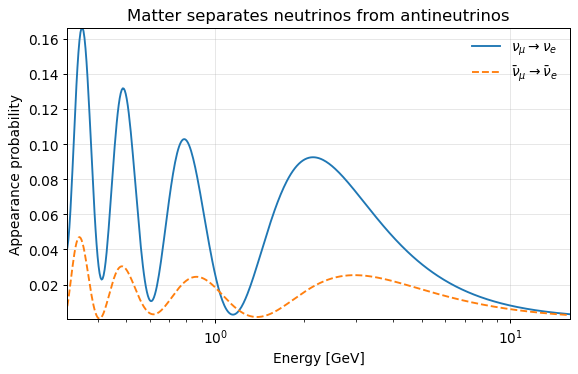

In [3]:
fig, ax = plt.subplots()
ax.semilogx(E_gev, p_nu[:, 3], label=r"$\nu_\mu \to \nu_e$")
ax.semilogx(E_gev, p_bar[:, 3], "--",
            label=r"$\bar\nu_\mu \to \bar\nu_e$")
ax.set_xlim(E_gev[0], E_gev[-1])
ax.set_xlabel("Energy [GeV]")
ax.set_ylabel("Appearance probability")
ax.set_title("Matter separates neutrinos from antineutrinos")
ax.legend()
plt.show()

## Getting it half right

The two common mistakes: flipping only the potential, or conjugating only the Hamiltonian. Both produce a smooth, plausible curve that is simply wrong.

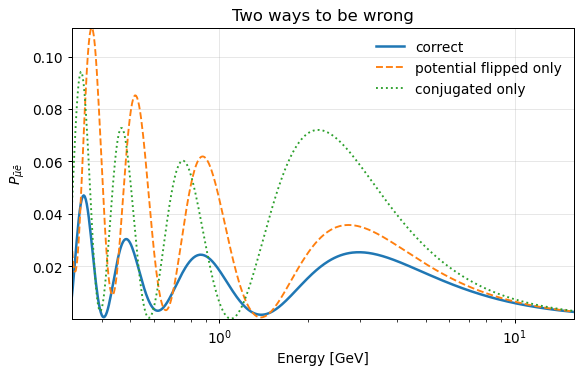

max error, potential only : 0.0872
max error, conjugate only : 0.0555


In [4]:
only_potential = oscprob3nu.probabilities_3nu(
    hamiltonians3nu.hamiltonian_3nu_matter(
        H_VAC_3NU, E, -gd.VCC_EARTH_CRUST), L)
only_conjugate = oscprob3nu.probabilities_3nu(
    hamiltonians3nu.hamiltonian_3nu_matter(
        np.conj(H_VAC_3NU), E, gd.VCC_EARTH_CRUST), L)

fig, ax = plt.subplots()
ax.semilogx(E_gev, p_bar[:, 3], lw=2.0, label="correct")
ax.semilogx(E_gev, only_potential[:, 3], "--",
            label="potential flipped only")
ax.semilogx(E_gev, only_conjugate[:, 3], ":",
            label="conjugated only")
ax.set_xlim(E_gev[0], E_gev[-1])
ax.set_xlabel("Energy [GeV]")
ax.set_ylabel(r"$P_{\bar\mu\bar e}$")
ax.set_title("Two ways to be wrong")
ax.legend()
plt.show()

print("max error, potential only : %.4f"
      % np.max(np.abs(p_bar[:, 3]-only_potential[:, 3])))
print("max error, conjugate only : %.4f"
      % np.max(np.abs(p_bar[:, 3]-only_conjugate[:, 3])))

## Checks that must hold

Two limits pin the treatment down. In **vacuum**, CPT requires $P(\nu_\alpha \to \nu_\beta) = P(\bar\nu_\beta \to \bar\nu_\alpha)$ — the transpose of the probability matrix. And with **$\delta_{CP} = 0$ and no matter**, neutrinos and antineutrinos are identical.

In [5]:
# CPT in vacuum: P_ab(nu) = P_ba(nubar)
e_one = 2.0*GEV
p_v = np.array(oscprob3nu.probabilities_3nu(
    np.asarray(H_VAC_3NU)/e_one, L)).reshape(3, 3)
p_v_bar = np.array(oscprob3nu.probabilities_3nu(
    np.conj(np.asarray(H_VAC_3NU))/e_one, L)).reshape(3, 3)

print("max |P(nu) - P(nubar)^T| in vacuum = %.2e"
      % np.max(np.abs(p_v - p_v_bar.T)))

max |P(nu) - P(nubar)^T| in vacuum = 0.00e+00


In [6]:
# delta_CP = 0 and no matter: the two are the same
h_nocp = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(
    gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF, 0.0,
    gd.D21_NO_BF, gd.D31_NO_BF)

a = np.array(oscprob3nu.probabilities_3nu(
    np.asarray(h_nocp)/e_one, L))
b = np.array(oscprob3nu.probabilities_3nu(
    np.conj(np.asarray(h_nocp))/e_one, L))
print("max |nu - nubar| with dCP = 0, vacuum = %.2e"
      % np.max(np.abs(a-b)))

max |nu - nubar| with dCP = 0, vacuum = 0.00e+00


## Through the Earth

The same rule applies to a slabbed calculation: conjugate the vacuum Hamiltonian and pass the negative potential. Because `earth` builds its Hamiltonians from the vacuum one it is given, the antineutrino case is one conjugation away — but the sign of the potential has to be handled where the potential is built, so the profile is assembled by hand here.

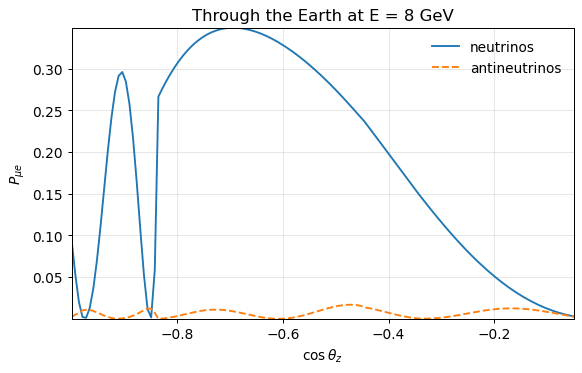

In [7]:
import earth
import slabs


def probabilities_earth_antinu(h_vac, energy, costhz,
                               n_slabs_per_segment=6):
    """Antineutrino probabilities across the Earth."""
    widths_km, densities = earth.earth_slabs(
        costhz, n_slabs_per_segment)
    vcc = -earth.matter_potential(densities)     # antineutrinos
    H = hamiltonians3nu.hamiltonian_3nu_matter(
        np.conj(h_vac), energy, vcc)             # antineutrinos
    return np.array(slabs.probabilities_3nu_slabs(
        H, widths_km*KM))


costhz = np.linspace(-0.999, -0.05, 140)
E_fixed = 8.0*GEV

p_nu = [earth.probabilities_3nu_earth(
    H_VAC_3NU, E_fixed, c, n_slabs_per_segment=6)[3]
    for c in costhz]
p_bar = [probabilities_earth_antinu(H_VAC_3NU, E_fixed, c)[3]
         for c in costhz]

fig, ax = plt.subplots()
ax.plot(costhz, p_nu, label="neutrinos")
ax.plot(costhz, p_bar, "--", label="antineutrinos")
ax.set_xlim(costhz[0], costhz[-1])
ax.set_xlabel(r"$\cos\theta_z$")
ax.set_ylabel(r"$P_{\mu e}$")
ax.set_title("Through the Earth at E = 8 GeV")
ax.legend()
plt.show()

---

**Previous:** [Mass ordering and the octant](12_ordering_and_octant.ipynb)  
**Next:** [Solar neutrinos and the MSW resonance](14_solar_and_adiabatic_msw.ipynb) --- the adiabatic resonance, and the limits of slabbing  
[API reference](https://mbustama.github.io/NuOscProbExact/functions.html) &middot; [Numerical recipes](https://mbustama.github.io/NuOscProbExact/recipes.html) &middot; [All notebooks](.)